In [1]:
#script to plot MZR plots across cosmic time
import os
import numpy as np
import h5py
import time
import cmasher as cm
import string
from pylab import genfromtxt
from pathlib import Path
import unyt
import pandas as pd
import h5py

import scipy.integrate as integrate
from scipy.optimize import curve_fit, root_scalar
from scipy.stats import gaussian_kde

import astropy.constants as cons
from astropy.cosmology import FlatLambdaCDM
from astropy import units as u
from astropy.io import fits

import matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import LogNorm, LinearSegmentedColormap
import matplotlib.ticker as mtickerbrms
from matplotlib.ticker import ScalarFormatter
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as colors
import matplotlib.patheffects as pe
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from my_funcs import *

COLIBRE_COLORS = [
    ('m5', '#C4E8FF'),
    ('m6', '#FF9F6E'),
    ('m7', '#D12424'),
]
PATH_EFFECTS = [pe.Stroke(linewidth=5, foreground="k"), pe.Normal()]
LINE_WIDTH = 3.5

defcolcycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

cosmo = FlatLambdaCDM(H0=68.1, Om0=0.306) #same parameters as Chaikin+25b (adopted by COLIBRE from Abbott et al. 2022)
masslimit_m5 = 2.3e5
masslimit_m6 = 1.84e6
masslimit_m7 = 1.47e7

masslimits = {"m5": masslimit_m5, "m6": masslimit_m6, "m7": masslimit_m7}
bbox = dict(boxstyle='round,pad=0.4',facecolor='white',edgecolor='black',alpha=0.9)

#path to store data of interest
#mypath = '/cosma8/data/do019/dc-shar7/mydata/'
#colibre runs stored at
#path = '/cosma8/data/dp004/colibre/Runs/'
#path to my home
#homepath = '/cosma/home/do019/dc-shar7/'
#path to EAGLE data
#eaglepath = '/snap8/scratch/dp004/dc-mcgi1/EAGLE/'
#path to TNG data
#tngpath = '/snap8/scratch/dp004/dc-mcgi1/TNG/'

simpath = 'simulated_data/'

/Applications/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Finished in 0.10 s


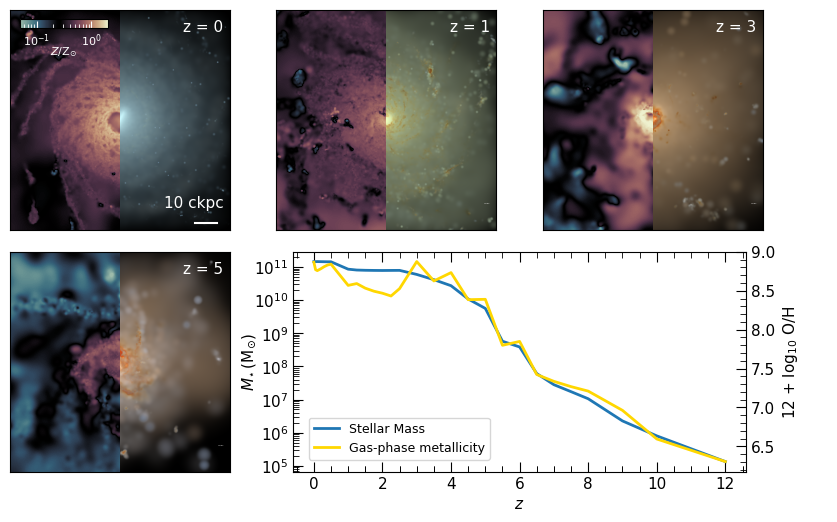

In [2]:
#Figure 1 of Sharda et al. 2026
_tstart = time.time()

f = plt.figure(figsize=(10, 6), constrained_layout=False)
gs = f.add_gridspec(2, 3, wspace=0.1, hspace=0.1, height_ratios=[1.00, 1.])
ax = np.empty((2, 3), dtype=object)
ax[0,0] = f.add_subplot(gs[0,0])
ax[0,1] = f.add_subplot(gs[0,1])
ax[0,2] = f.add_subplot(gs[0,2])
ax[1,0] = f.add_subplot(gs[1,0])
ax[1,1] = f.add_subplot(gs[1,1:3])

# remove the original wide axis
ax[1,1].remove()
# create a smaller one in the same grid cell
parent = f.add_subplot(gs[1,1:3])
ax[1,1] = inset_axes(parent, width="89%", height="100%", loc='center')
# optionally turn off the parent axis
parent.set_axis_off()


fontsize = 11

snaps = ['0127', '0092', '0064', '0048']
zz = [0, 1, 3, 5]
track_id = 918

lw = 2
lower, upper = 0.1, 1
n_colors = 100
new_colors = cm.copper_s_r(np.linspace(lower, upper, n_colors))
cmap_z = LinearSegmentedColormap.from_list('cropped_copper_s_r', new_colors)

vmin_z, vmax_z = 0.05, 2
vmin_m, vmax_m = 1e-2, 1e5
obsv = 'jwst'
for idx, snap in enumerate(snaps):

    i, j = divmod(idx, 3)

    # ---------------- METALLICITY ----------------
    bb = np.load(simpath+
                 f'projection_metallicity_{snap}_excl_50kpc_comoving_trackId_{str(track_id).zfill(8)}.npy').T

    im_z = ax[i, j].imshow(bb[:, 0:250] / 0.0134, origin='lower', norm=LogNorm(vmin=vmin_z, vmax=vmax_z), cmap=cmap_z,
                           extent=[0, 250, 0, 500])

    cc = np.load(simpath+
                 f'partridge_50kpc_comoving_snap_{snap}_trackID_{str(track_id).zfill(3)}_{obsv}.npy')

    im_m = ax[i, j].imshow(cc[:, 250:], extent=[250, 500, 0, 500])

    ax[i,j].set_xticks([])
    ax[i,j].set_yticks([])
    ax[i, j].text(0.97, 0.92, f'z = {zz[idx]}', ha='right', va='center', fontsize=fontsize, 
                  transform=ax[i, j].transAxes, color='white')
    ax[i, j].set_xticklabels([])
    ax[i, j].set_yticklabels([])

    if i==0 and j==0:
        ax[i, j].plot([420, 420+51.2], [15, 15], c='white')
        ax[i, j].text(0.97, 0.12, '10 ckpc', ha='right', va='center', fontsize=fontsize, 
                      transform=ax[i, j].transAxes, color='white')
    else:
        ax[i, j].plot([420, 420+51.2], [15, 15], c='k', ls='None')
        ax[i, j].text(0.97, 0.12, '10 ckpc', ha='right', va='center', fontsize=0, 
                      transform=ax[i, j].transAxes, color='white')

bb=pd.read_csv(simpath+'colibre_l025m5_trackID_918_fig1.csv')

ax[1,1].plot(bb['z'], bb['Mstar'], label='Stellar Mass',lw=2)
ax2 = ax[1,1].twinx()
ax2.plot(bb['z'], bb['12+log(O/H)'], c='gold',label='Gas-phase metallicity',lw=2)
ax[1,1].set_yscale('log')
ax[1,1].legend(loc='lower left',fontsize=fontsize-2,bbox_to_anchor=(0.02,0.025))
ax[1,1].set_xlabel(r'$z$', fontsize=fontsize)
ax[1,1].set_ylabel(r'$M_{\star}\,(\rm{M_{\odot}})$', fontsize=fontsize,labelpad=-3)
ax2.set_ylabel(r'12 + $\log_{10}\,\rm{O/H}$', fontsize=fontsize)

cax = f.add_axes([ax[0,0].get_position().x0 + 0.01,
                  ax[0,0].get_position().y1 - 0.03,
                  ax[0,0].get_position().width * 0.4,
                  0.015])

cb = plt.colorbar(im_z, cax=cax, orientation='horizontal')
cb.set_label(r'$Z/\rm{Z_{\odot}}$', fontsize=8, color='white',labelpad=-3)
cb.ax.tick_params(which='major',direction='in',labelsize=8,length=5,colors='white')
cb.ax.tick_params(which='minor',direction='in',labelsize=8,length=3,color='white')

color='k'
ax[1,1].tick_params(axis='both', which='major', direction = 'in', top=True, right=False, labelsize=fontsize, length=7, color=color)
ax[1,1].minorticks_on()
ax[1,1].tick_params(axis='both', which='minor', direction = 'in', top=True, right=False, labelsize=fontsize, length=4, color=color)

ax2.tick_params(axis='both', which='major', direction = 'in', top=False, right=True, left=False, labelsize=fontsize, length=7, color=color)
ax2.minorticks_on()
ax2.tick_params(axis='both', which='minor', direction = 'in', top=False, right=True, left=False, labelsize=fontsize, length=4, color=color)

print(f"Finished in {time.time() - _tstart:.2f} s")
#f.savefig('Figure1.png', bbox_inches='tight', dpi=300)


Cell took 0.05 s


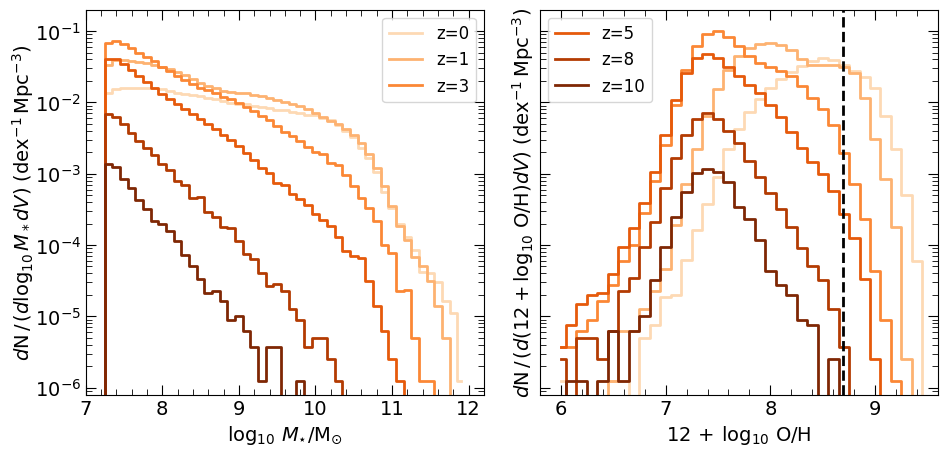

In [3]:
#Figure 2

_tstart = time.time()
f, ax = plt.subplots(1,2, figsize=(11, 5),gridspec_kw = {'hspace':0., 'wspace':0.14})
fontsize=14
min_count=20
reslimit_count=10

cmap = plt.cm.Oranges
# 5 evenly spaced values between 0 and 1
colorss = cmap(np.linspace(0.2, 1, 6))

zz = [0, 1, 3, 5, 8, 10]
lw=2


bb=np.load(simpath+'figure2_data.npz', allow_pickle=True)


for idx in range(0, len(zz)):
    if zz[idx]<=3:
        ax[0].step(bb['bin_centers0'][idx], bb['phi0'][idx], where='mid', color=colorss[idx], lw=lw, 
                   label=r'z=%d' % zz[idx])
    else:
        ax[0].step(bb['bin_centers0'][idx], bb['phi0'][idx], where='mid', color=colorss[idx], lw=lw)
    
    if zz[idx] > 3:
        ax[1].step(bb['bin_centers1'][idx], bb['phi1'][idx], where='mid', color=colorss[idx], lw=lw, 
                   label=r'z=%d' % zz[idx])
    else:
        ax[1].step(bb['bin_centers1'][idx], bb['phi1'][idx], where='mid', color=colorss[idx], lw=lw)

ax[1].axvline(x=8.69, c='k', lw=lw, ls='dashed')
set_allticks(ax[0], fontsize=fontsize)
set_allticks(ax[1], fontsize=fontsize)
ax[0].set_yscale('log')
ax[1].set_yscale('log')
ax[0].set_ylim(8e-7, 2e-1)
ax[1].set_ylim(8e-7, 2e-1)
ax[0].set_xlim(7, 12.2)
ax[1].set_xlim(5.8, 9.6)
ax[0].legend(fontsize=fontsize-2, loc='upper right', ncol=1)
ax[1].legend(fontsize=fontsize-2, loc='upper left', ncol=1)
ax[1].set_yticklabels([])
ax[0].set_ylabel(r'$d\mathrm{N}\,/\,\left(d\log_{10}M_* dV\right)$ ($\rm{dex^{-1}\,Mpc^{-3}}$)', fontsize=fontsize, labelpad=-1)
ax[1].set_ylabel(r'$d\mathrm{N}\,/\,\left(d(12+\log_{10}\,\mathrm{O/H}) dV\right)$ ($\rm{dex^{-1}\,Mpc^{-3}}$)', fontsize=fontsize, labelpad=-1)
ax[0].set_xlabel(r'$\log_{10}\,M_{\star}/\rm{M_{\odot}}$', fontsize=fontsize)
ax[1].set_xlabel(r'$12\,+\,\log_{10}\,\rm{O/H}$', fontsize=fontsize)

#f.savefig('Figure2.pdf', bbox_inches='tight')
print(f"Cell took {time.time() - _tstart:.2f} s")



Observational data plotted
Cell took 0.67 s


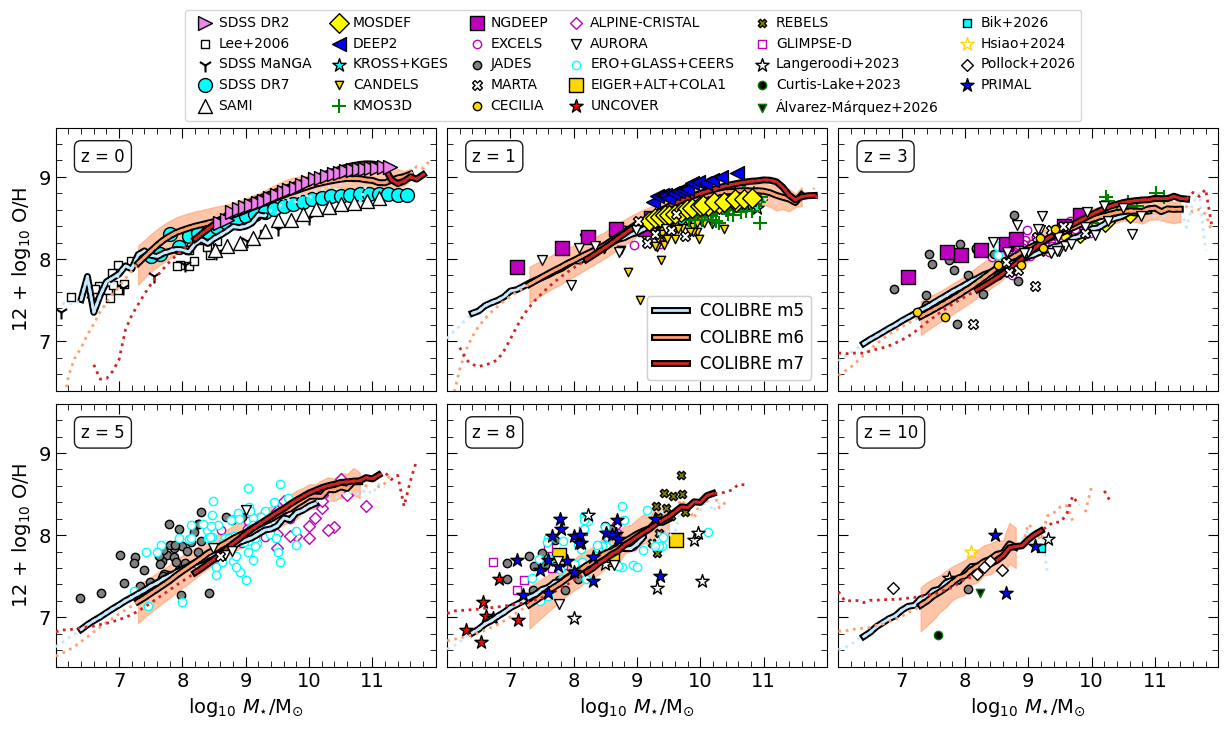

In [3]:
_tstart = time.time()
f, ax = plt.subplots(2,3, figsize=(15, 7), gridspec_kw = {'wspace':0.03, 'hspace':0.05})
fontsize=14
min_count = 20 #need minimum "min_count" galaxies per bin
reslimit_count = 10 #need minimum "reslimit_count" star particles in a galaxy


plot_obsv_data(ax, zorder=3)
print('Observational data plotted')
bbox = dict(boxstyle='round,pad=0.4',facecolor='white',edgecolor='black',alpha=0.9)

snaps = ['0127', '0092', '0064', '0048', '0026', '0018']
zz = [0, 1, 3, 5, 8, 10]
lw=2
handletextpad=0.01
for idx, snap in enumerate(snaps):

    i, j = divmod(idx, 3)

    model='m5'
    bb = np.load(simpath+f'plot_mzr_sims_data_{model}_{zz[idx]}.npz')
    #flag galaxies with < min_count and < reslimit_count
    mask = (bb['counts'] >= min_count) & (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=COLIBRE_COLORS[0][1], path_effects=PATH_EFFECTS, zorder=4)
    mask = (bb['counts'] >= min_count)
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=COLIBRE_COLORS[0][1], ls='dotted', zorder=4)
    mask = (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=COLIBRE_COLORS[0][1], ls='dotted', zorder=4)

    model='m6'
    bb = np.load(simpath+f'plot_mzr_sims_data_{model}_{zz[idx]}.npz')
    #flag galaxies with < min_count and < reslimit_count
    mask = (bb['counts'] >= min_count) & (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=COLIBRE_COLORS[1][1], path_effects=PATH_EFFECTS, zorder=4)
    #plot 16/84 percentile scatter
    ax[i][j].fill_between(bb['bin_centers'][mask], bb['p16'][mask], bb['p84'][mask], color=COLIBRE_COLORS[1][1], alpha=0.6, zorder=1)
    mask = (bb['counts'] >= min_count)
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=COLIBRE_COLORS[1][1], ls='dotted', zorder=4)
    mask = (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=COLIBRE_COLORS[1][1], ls='dotted', zorder=4)

    model='m7'
    bb = np.load(simpath+f'plot_mzr_sims_data_{model}_{zz[idx]}.npz')
    #flag galaxies with < min_count and < reslimit_count
    mask = (bb['counts'] >= min_count) & (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=COLIBRE_COLORS[2][1], path_effects=PATH_EFFECTS, zorder=4)
    mask = (bb['counts'] >= min_count)
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=COLIBRE_COLORS[2][1], ls='dotted', zorder=4)
    mask = (10**bb['bin_centers'] >= reslimit_count * masslimits[model])
    ax[i][j].plot(bb['bin_centers'][mask], bb['medians'][mask], lw=2, color=COLIBRE_COLORS[2][1], ls='dotted', zorder=4)

    set_allticks(ax[i][j], fontsize=fontsize)
    ax[i][j].set_xticks([7, 8, 9, 10, 11])
    ax[i][j].set_ylim(6.4, 9.6)
    ax[i][j].set_xlim(6, 12)
    ax[i][j].text(6.4, 9.25, 'z = %d'%zz[idx], ha='left', va='center', fontsize=fontsize-2, bbox=bbox)
    if i==1:
        ax[i][j].set_xlabel(r'$\log_{10}\,M_{\star}/\rm{M_{\odot}}$', fontsize=fontsize)
    else:
        ax[i][j].set_xticklabels([])
    if j==0:
        ax[i][j].set_ylabel(r'$12\,+\,\log_{10}\,\rm{O/H}$', fontsize=fontsize)
    else:
        ax[i][j].set_yticklabels([])

ax[0][1].plot(bb['bin_centers']*0, bb['medians']*0, lw=lw, color=COLIBRE_COLORS[0][1],path_effects=PATH_EFFECTS)
ax[0][1].plot(bb['bin_centers']*0, bb['medians']*0, lw=lw, color=COLIBRE_COLORS[1][1],path_effects=PATH_EFFECTS)
ax[0][1].plot(bb['bin_centers']*0, bb['medians']*0, lw=lw, color=COLIBRE_COLORS[2][1],path_effects=PATH_EFFECTS)
lines=ax[0][1].get_lines()
aa=len(lines)-1
legend2 = ax[0][1].legend([lines[i] for i in [aa-2, aa-1, aa]], [r'COLIBRE '+COLIBRE_COLORS[0][0], 
                                                                   r'COLIBRE '+COLIBRE_COLORS[1][0], 
                                                                   r'COLIBRE '+COLIBRE_COLORS[2][0]], 
                     loc='lower right', fontsize=fontsize-2, ncol=1, bbox_to_anchor=(0.98, 0.01))
ax[0][1].add_artist(legend2)



# COMBINED LEGEND
handles_all = []
labels_all = []

for axi in ax.flat:

    h, l = axi.get_legend_handles_labels()

    handles_all.extend(h)
    labels_all.extend(l)

# Remove duplicates while preserving order
unique = {}

for h, l in zip(handles_all, labels_all):

    # Skip COLIBRE legend entries
    if 'COLIBRE' in l:
        continue

    if l not in unique:
        unique[l] = h

fig_legend = f.legend(
    unique.values(),
    unique.keys(),
    loc='lower center',
    bbox_to_anchor=(0.51, 0.88),
    ncol=6,
    fontsize=fontsize-4,
    frameon=True,
    handletextpad=0.01,
    columnspacing=1.0
)


#f.savefig('Figure3.pdf', bbox_inches='tight')
print(f"Cell took {time.time() - _tstart:.2f} s")

